In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('card_transdata.csv')
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**EDA**

Now that the data is loaded, we can begin EDA

In [4]:
print("shape:",data.shape) #large dataset: 1,000,000 rows
data.info()
data.value_counts()

shape: (1000000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


distance_from_home  distance_from_last_transaction  ratio_to_median_purchase_price  repeat_retailer  used_chip  used_pin_number  online_order  fraud
0.004874            0.198102                        0.998148                        0.0              0.0        0.0              1.0           0.0      1
18.271839           0.558001                        0.161158                        1.0              0.0        0.0              1.0           0.0      1
18.271944           0.079844                        0.264669                        1.0              0.0        0.0              0.0           0.0      1
18.271993           1.078692                        0.712373                        1.0              0.0        0.0              1.0           0.0      1
18.272016           0.197228                        0.615863                        1.0              0.0        0.0              0.0           0.0      1
                                                                                 

In [5]:
#check for missing values
print(data.isna().values.any())
print(data.isnull().values.any())

False
False


This dataset contains no missing values.

Now, let's plot the target variable, which is 'fraud'. 'Fraud' is a categorical variable where an output of 0 means that the transaction was not fraudulent and an output of 1 means that it was. Let's find out what percentage of all transactions in this data
set were fraudulent.

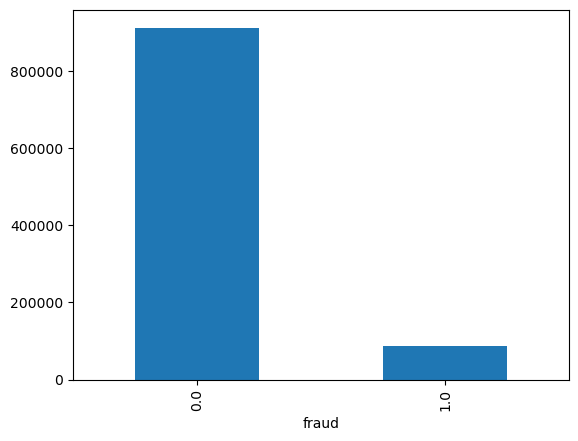

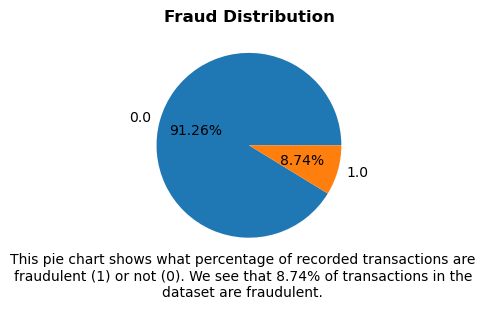

In [6]:
#TARGET VARIABLE
#bar plot
data['fraud'].value_counts().plot(kind='bar')

#pie plot

import matplotlib
import matplotlib.pyplot as plt


#pie chart
plt.figure(figsize = (5, 3))
plt.pie(x = data['fraud'].value_counts().values,
        labels = data['fraud'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Fraud Distribution', size = 12, weight = 'bold')
caption = "This pie chart shows what percentage of recorded transactions are fraudulent (1) or not (0). We see that 8.74% of transactions in the dataset are fraudulent."
plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()
#only 8.74% of all transactions are fraudulent


We can see that 8.74% of all transactions in our dataset were fraudulent.


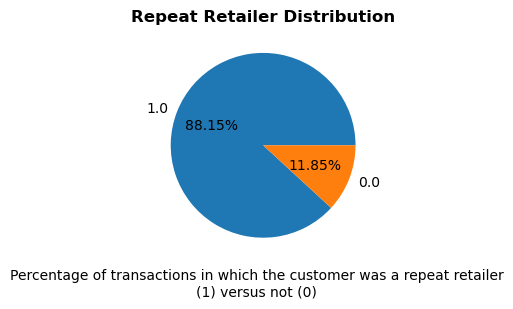

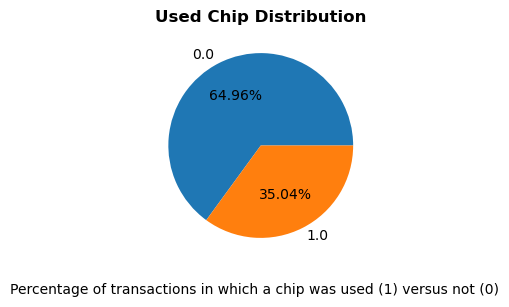

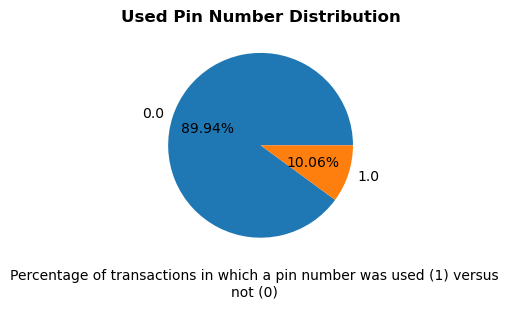

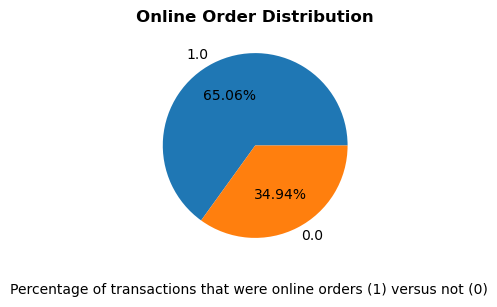

In [18]:
#Non-target categorical variables

plt.figure(figsize = (5, 3))
plt.pie(x = data['repeat_retailer'].value_counts().values,
        labels = data['repeat_retailer'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Repeat Retailer Distribution', size = 12, weight = 'bold')
caption = "Percentage of transactions in which the customer was a repeat retailer (1) versus not (0)"
plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

plt.figure(figsize = (5, 3))
plt.pie(x = data['used_chip'].value_counts().values,
        labels = data['used_chip'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Used Chip Distribution', size = 12, weight = 'bold')
caption = "Percentage of transactions in which a chip was used (1) versus not (0)"
plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()


plt.figure(figsize = (5, 3))
plt.pie(x = data['used_pin_number'].value_counts().values,
        labels = data['used_pin_number'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Used Pin Number Distribution', size = 12, weight = 'bold')
caption = "Percentage of transactions in which a pin number was used (1) versus not (0)"
plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

plt.figure(figsize = (5, 3))
plt.pie(x = data['online_order'].value_counts().values,
        labels = data['online_order'].value_counts().index, 
        autopct = '%1.2f%%')
caption = "Percentage of transactions that were online orders (1) versus not (0)"
plt.title('Online Order Distribution', size = 12, weight = 'bold')
plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

fraud               0.0    1.0
used_pin_number               
0.0              812262  87130
1.0              100335    273


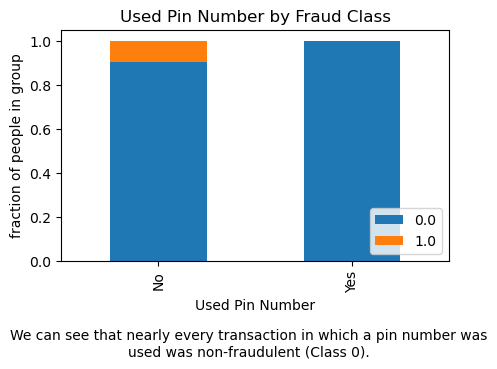

fraud         0.0    1.0
used_chip               
0.0        584608  64993
1.0        327989  22410


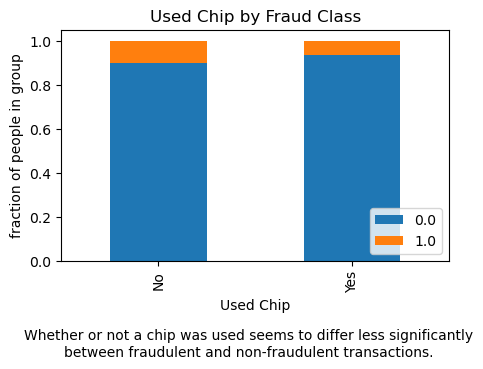

fraud               0.0    1.0
repeat_retailer               
0.0              107986  10478
1.0              804611  76925


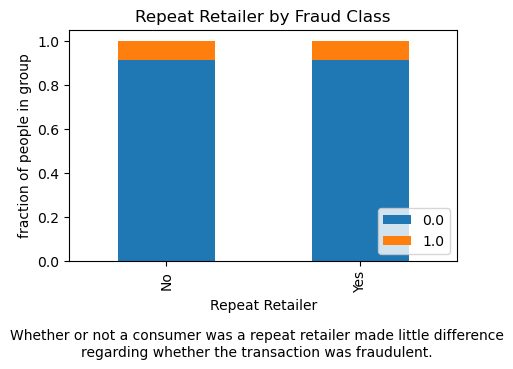

fraud            0.0    1.0
online_order               
0.0           344756   4692
1.0           567841  82711


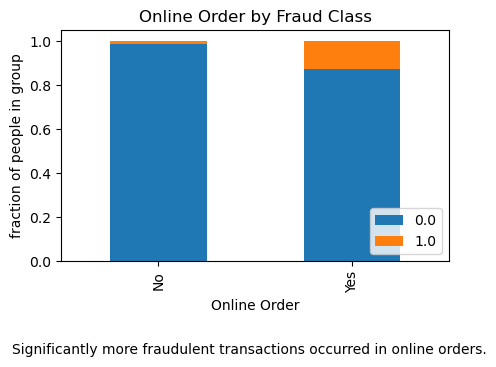

In [8]:
#CATEGORICAL VERSUS CATEGORICAL

count_matrix = data.groupby(['used_pin_number', 'fraud']).size().unstack()
print(count_matrix)

count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
ax = count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))

# Setting the tick labels
new_labels = ['No', 'Yes']  # Replace with your own labels
ax.set_xticklabels(new_labels)
plt.xlabel('Used Pin Number')
plt.ylabel('fraction of people in group')
plt.legend(loc=4)
plt.title('Used Pin Number by Fraud Class')
caption = "We can see that nearly every transaction in which a pin number was used was non-fraudulent (Class 0)."
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)
 
plt.show()

#We can see that nearly every transaction that used a pin number was NON-FRAUDULENT


count_matrix = data.groupby(['used_chip', 'fraud']).size().unstack()
print(count_matrix)

count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
ax = count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))

# Setting the tick labels
new_labels = ['No', 'Yes']  # Replace with your own labels
ax.set_xticklabels(new_labels)
plt.xlabel('Used Chip')
plt.ylabel('fraction of people in group')
plt.legend(loc=4)
plt.title('Used Chip by Fraud Class')
caption = "Whether or not a chip was used seems to differ less significantly between fraudulent and non-fraudulent transactions."
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)
 
plt.show()


count_matrix = data.groupby(['repeat_retailer', 'fraud']).size().unstack()
print(count_matrix)

count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)

ax = count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))

# Setting the tick labels
new_labels = ['No', 'Yes']  # Replace with your own labels
ax.set_xticklabels(new_labels)
plt.xlabel('Repeat Retailer')
plt.ylabel('fraction of people in group')
plt.legend(loc=4)
plt.title('Repeat Retailer by Fraud Class')
caption = "Whether or not a consumer was a repeat retailer made little difference regarding whether the transaction was fraudulent."
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)
 
plt.show()

count_matrix = data.groupby(['online_order', 'fraud']).size().unstack()
print(count_matrix)

count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
ax = count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))

# Setting the tick labels
new_labels = ['No', 'Yes']  # Replace with your own labels
ax.set_xticklabels(new_labels)
plt.xlabel('Online Order')
plt.ylabel('fraction of people in group')
plt.legend(loc=4)
plt.title('Online Order by Fraud Class')
caption = "Significantly more fraudulent transactions occurred in online orders."
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)
 
plt.show()




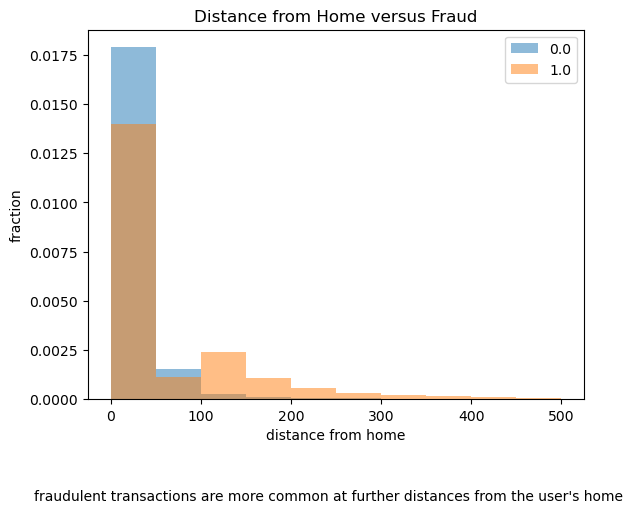

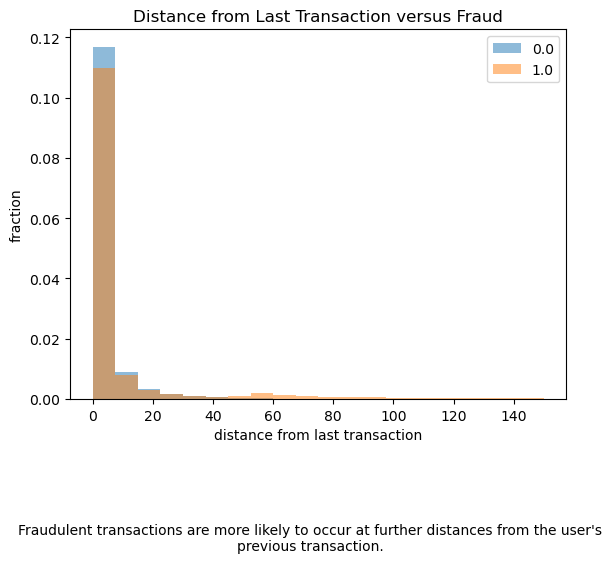

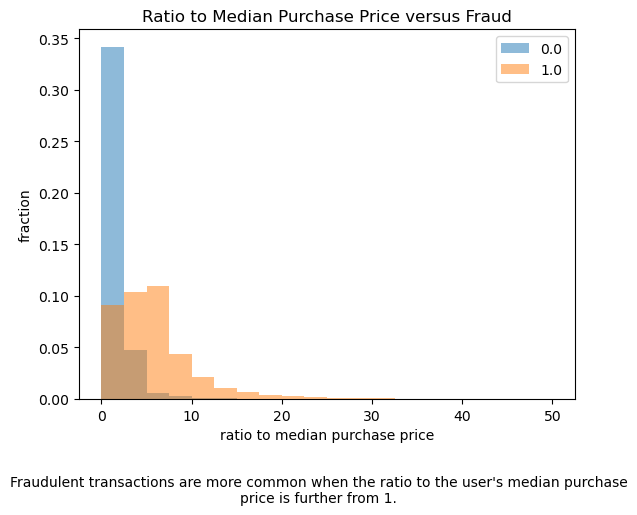

In [9]:
#histogram
#continuous to categorical: distance_from_home
categories = data['fraud'].unique()
bin_range = (data['distance_from_home'].min(), 500
            )


for c in categories:
    plt.hist(data[data['fraud']==c]['distance_from_home'],alpha=0.5,label=c,range=bin_range,bins=10,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from home')
plt.title('Distance from Home versus Fraud')
caption = ("fraudulent transactions are more common at further distances from the user's home")
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()


categories2 = data['fraud'].unique()
bin_range2 = (data['distance_from_home'].min(), 150
              
            )



for c in categories2:
    plt.hist(data[data['fraud']==c]['distance_from_last_transaction'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from last transaction')
plt.title('Distance from Last Transaction versus Fraud')
caption =("Fraudulent transactions are more likely to occur at further distances from the user's previous transaction.")
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()


#RATIO
categories3= data['fraud'].unique()
bin_range2 = (data['ratio_to_median_purchase_price'].min(), 50
            )


for c in categories3:
    plt.hist(data[data['fraud']==c]['ratio_to_median_purchase_price'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('ratio to median purchase price')
plt.title('Ratio to Median Purchase Price versus Fraud')
caption = ("Fraudulent transactions are more common when the ratio to the user's median purchase price is further from 1.")
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()



<Axes: >

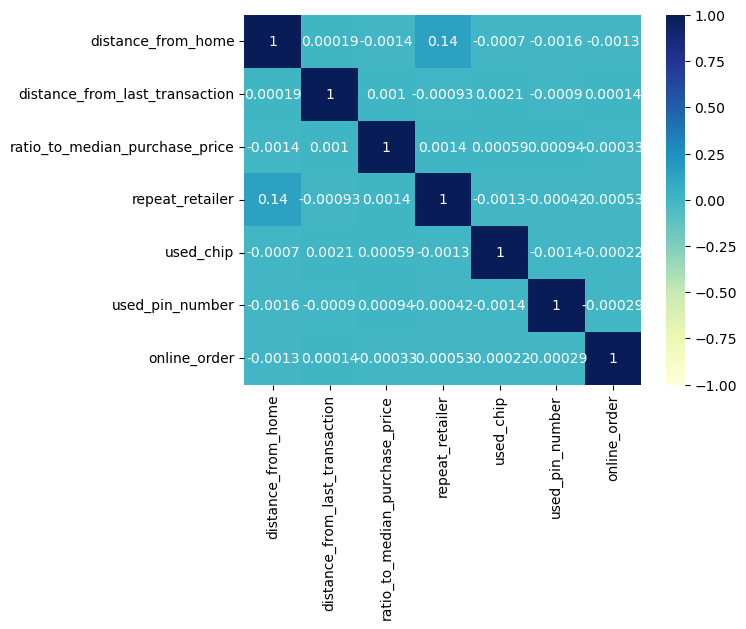

In [10]:
#check for correlated features
X = data.loc[:,data.columns != 'fraud']
y=data['fraud']

import seaborn as sns
corr_matrix = X.corr(method='pearson', min_periods=1, numeric_only=False) 

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="YlGnBu")

We can see that none of the features are closely correlated, meaning we do not need to get rid of features to improve the convergence time of the model.

**Split Data**

Since this is a large dataset, 98% of data will be in the training set, 1% in the validation set, and 1% in the test set. The data is unbalanced, so I will be using the 'stratify' argument in train_test_split.


In [11]:
print(y.value_counts())

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
#identify feature matrix and target feature
X=data.loc[:,data.columns != 'fraud']
y=data['fraud']

#stratified train_test_split
random_state = 42

X_train, X_other, y_train, y_other = train_test_split(X,y,train_size = 0.98,stratify=y,random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
print('**balance with stratification:**')
print(np.unique(y_train,return_counts=True))
print(np.unique(y_val,return_counts=True))
print(np.unique(y_test,return_counts=True))

print('validation set:',X_val.shape, y_val.shape) # 1% of points are in validation
print('test set:',X_test.shape, y_test.shape) # 1% of points are in test
print('train set:', X_train.shape, y_train.shape) #98% of points are in train
print(X_train.head())



**balance with stratification:**
(array([0., 1.]), array([894345,  85655]))
(array([0., 1.]), array([9126,  874]))
(array([0., 1.]), array([9126,  874]))
validation set: (10000, 7) (10000,)
test set: (10000, 7) (10000,)
train set: (980000, 7) (980000,)
        distance_from_home  distance_from_last_transaction  \
773522            7.437069                        2.516719   
756690           14.028811                        0.493430   
801928          120.716495                        0.021280   
801345            1.683694                        0.346633   
283515           14.249239                        0.591916   

        ratio_to_median_purchase_price  repeat_retailer  used_chip  \
773522                        0.608334              1.0        1.0   
756690                        0.719204              1.0        0.0   
801928                        0.966234              1.0        0.0   
801345                        2.435943              0.0        1.0   
283515                  

**Preprocessing**

Categorical features: repeat_retailer, used_chip, used_pin_number, online_order
Continuous features: distance_from_home, distance_from_last_transaction, ratio_to_median_purchase_price

The continuous features all follow a tail distribution so I will preprocess them using StandardScaler.
I'll use OneHotEncoder to preprocess the categorical variables. Even though they don't necessarily need to be preprocessed since they are already zeroes and ones and there are no missing values, I will run OneHotEncoder so I don't have to re-append the columns to my preprocoessed data.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

preprocessor = ColumnTransformer(
   transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), ftrs)])


clf = Pipeline(steps=[('preprocessor', preprocessor)])

X_train_prep = clf.fit_transform(X_train)
X_val_prep = clf.fit_transform(X_val)
X_test_prep = clf.fit_transform(X_test)

print("X train shape", X_train.shape)
print("X train prep shape", X_train_prep.shape)
print("X train prep:", X_train_prep)


#initialize the encoder
enc = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
# fit encoder
enc.fit(X_train[cat_ftrs])
# transform X_train
onehot_train = enc.transform(X_train[cat_ftrs])
print('transformed train features:')
print(onehot_train)
# transform X_val
onehot_val = enc.transform(X_val[cat_ftrs])
print('transformed val features:')
print(onehot_val) 
# transform X_test
onehot_test = enc.transform(X_test[cat_ftrs])
print('transformed test features:')
print(onehot_test)


X train shape (980000, 7)
X train prep shape (980000, 11)
X train prep: [[ 0.          1.          0.         ... -0.29324088 -0.09715076
  -0.43414526]
 [ 0.          1.          1.         ... -0.19258739 -0.1751522
  -0.39457111]
 [ 0.          1.          1.         ...  1.43649443 -0.19335442
  -0.30639616]
 ...
 [ 0.          1.          0.         ... -0.33764006  1.57622055
   0.00236275]
 [ 0.          1.          1.         ... -0.11499707 -0.1772184
  -0.59175009]
 [ 0.          1.          1.         ... -0.35901419  0.14317666
  -0.48900832]]
transformed train features:
[[0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 1. 1. 0.]
 [0. 1. 1. ... 0. 0. 1.]]
transformed val features:
[[0. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 [0. 1. 1. ... 0. 0. 1.]
 ...
 [0. 1. 0. ... 0. 0. 1.]
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 1.]]
transformed test features:
[[0. 1. 0. ... 1. 0. 1.]
 [1. 0. 1. ... 0. 1.